# Deconvolve Chromatin - Refactor and Find Gamma


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [3]:
chromatin_gridder.set_gene('SSK22')

In [4]:
chromatin_gridder.create_bins_per_all_sample()

The histogram shape around the TSS is: (3, 9)


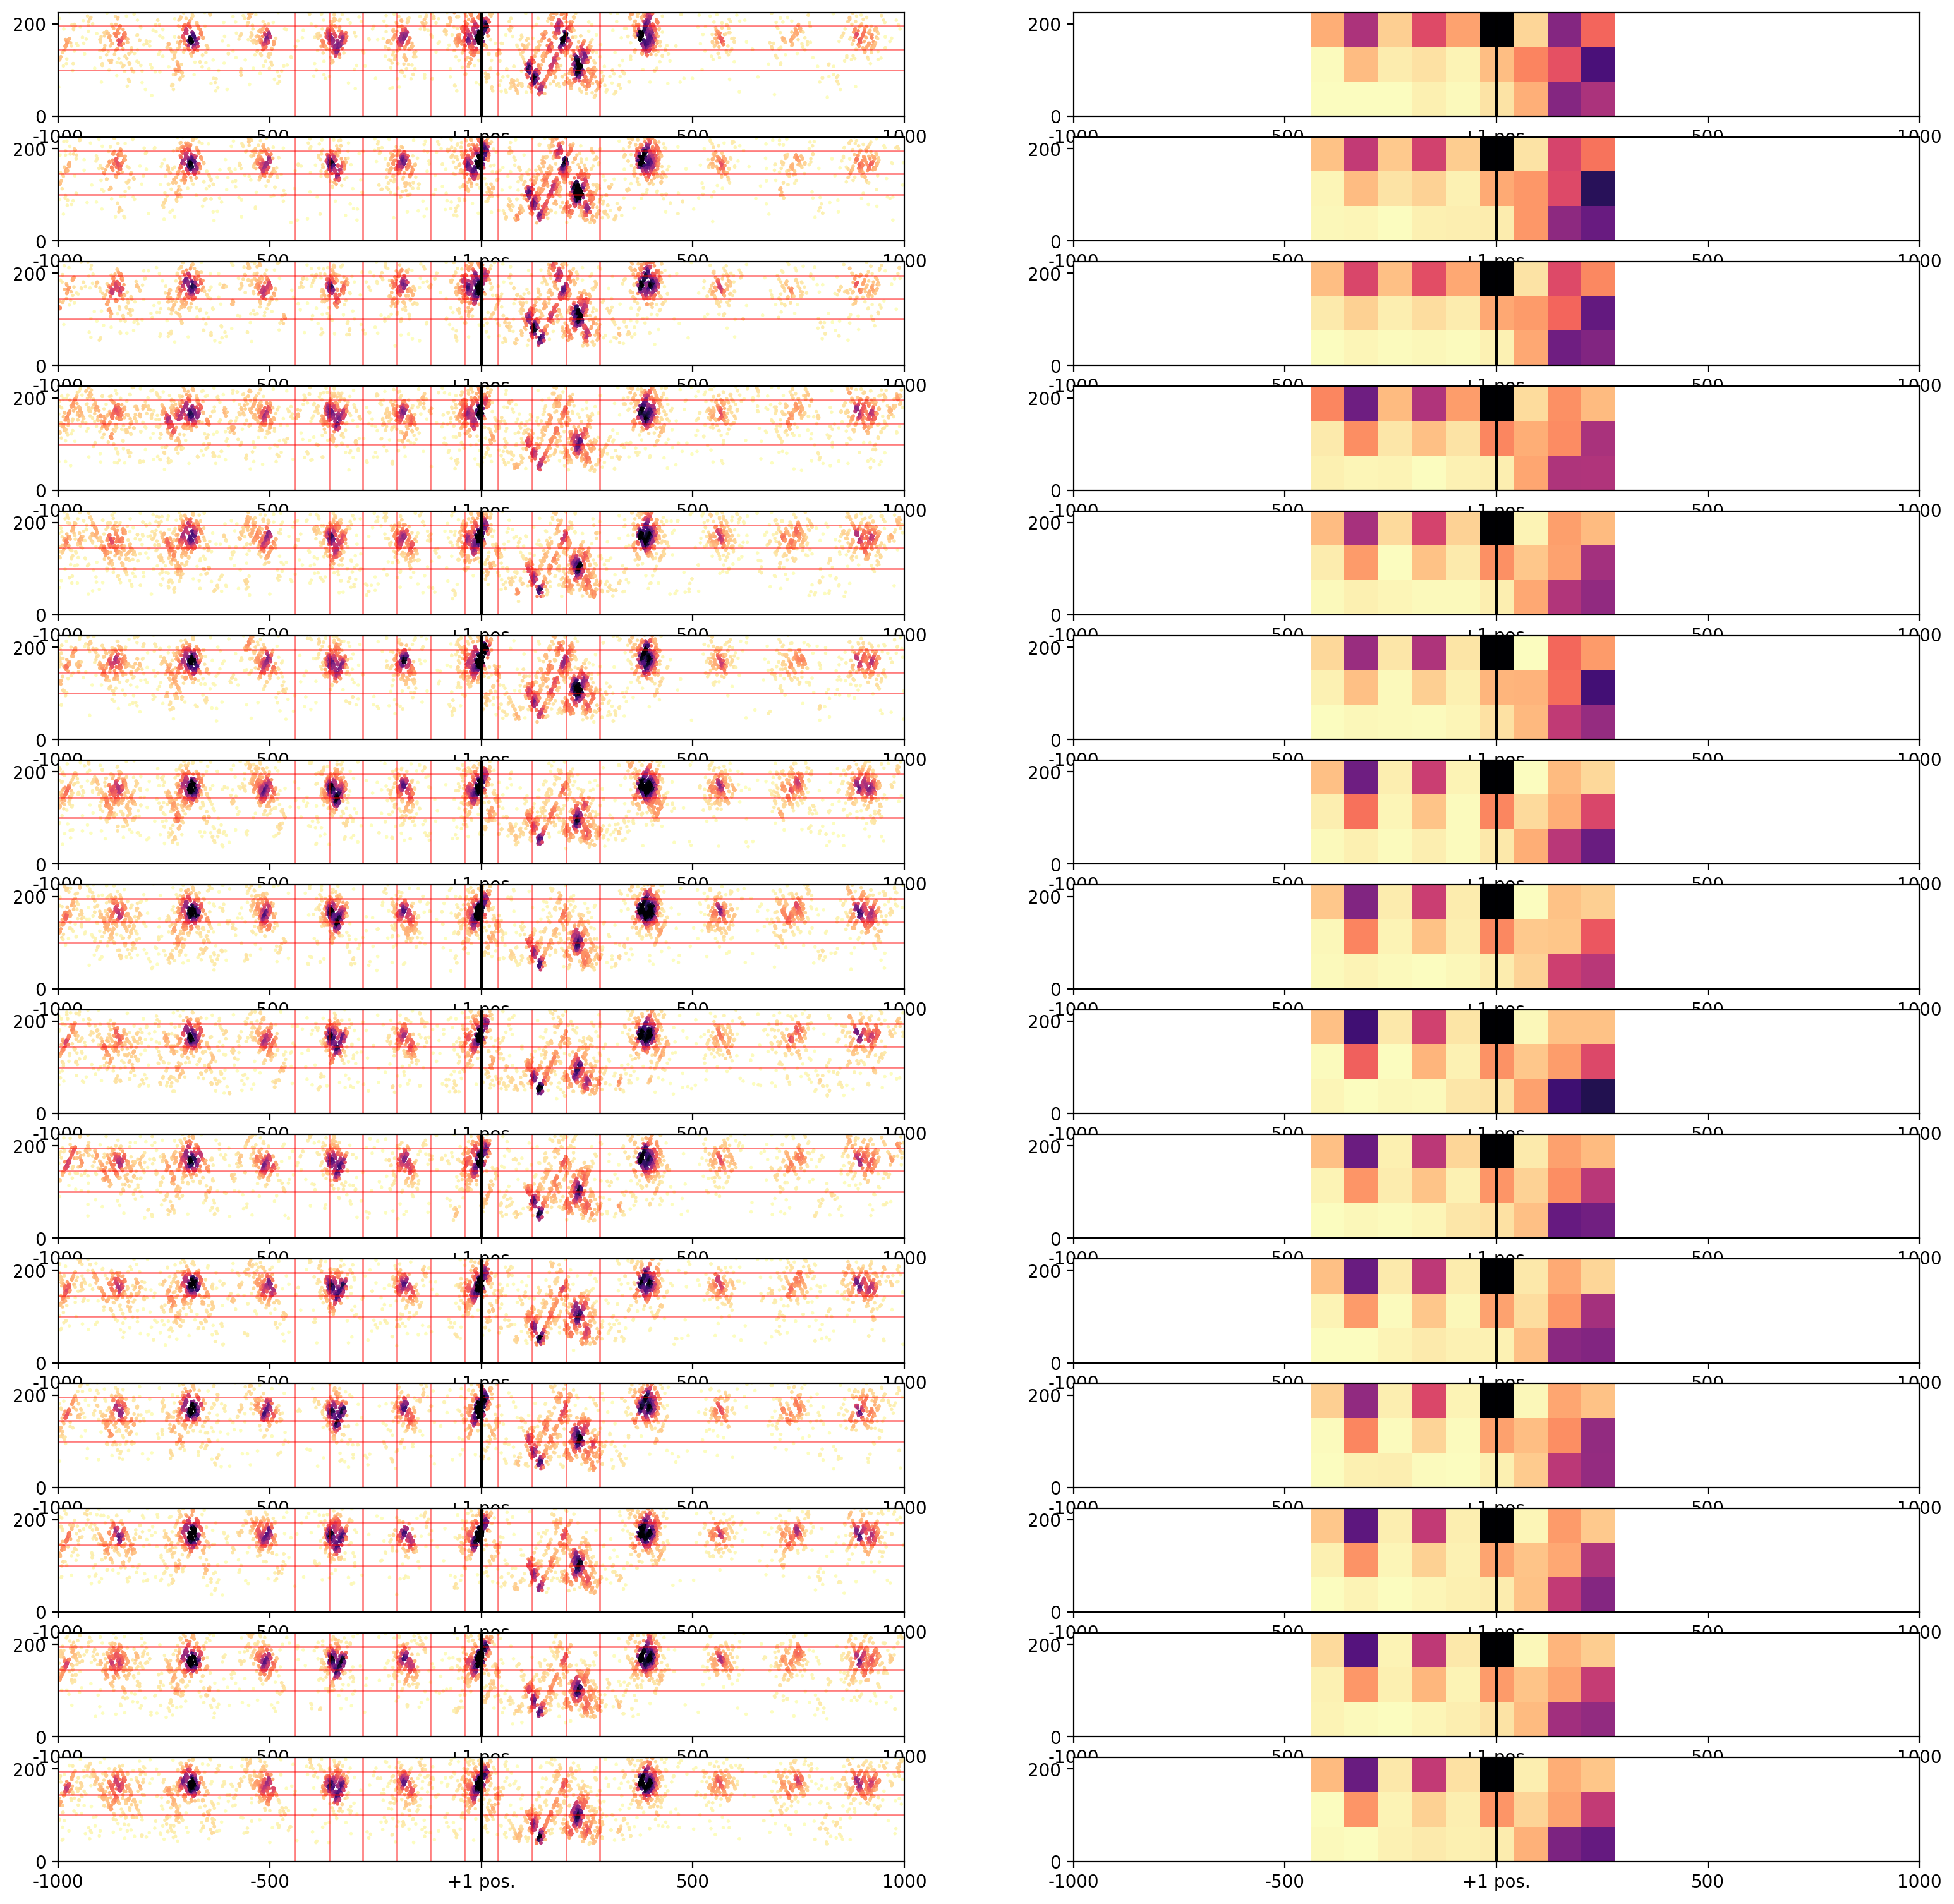

In [5]:
chromatin_gridder.plot_raw_and_grid()

The first histogram is shape: (3, 9)
Reshaping this histogram to a vector of shape: (27,)
Then, if we were to take that first vector and restore it to its original shape: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


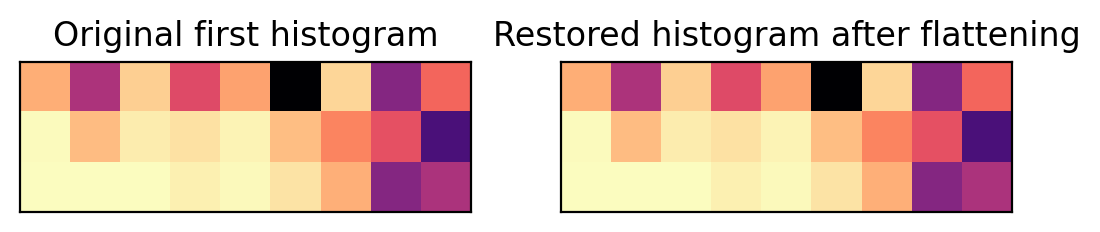

In [6]:
chromatin_gridder.create_deconvolution_matrices(plot=True)

In [7]:
from src.config import load_yl_replicate2_rg1_chromatin_config, \
    load_xg_gene_expression_config
from src.model import Model

config = load_yl_replicate2_rg1_chromatin_config()
model = Model(config, 'SSK22', 0.1)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

The shape of the convolution kernel matrix, H is:  (15, 226)


In [ ]:
from src.deconvolve_chromatin import plot_deconvolved_chromatin
from src.deconvolve_chromatin import deconvolve_chromatin
from src.timer import Timer

timer = Timer()
result, f = deconvolve_chromatin(model, chromatin_gridder.deconv_hist)
print(f"Completed in {timer.get_time()}")
print(f"  The result was {result:.2f} and an F matrix of size {f.shape}")

In [ ]:
plot_deconvolved_chromatin(model.H, f, chromatin_gridder.deconv_hist)

In [ ]:
chromatin_gridder.create_deconvolution_plots(f, model)

In [ ]:
chromatin_gridder.plot_prediction_comparison(model, f)

In [8]:
from src.find_gamma_chromatin import FindOptimalGammaChromatin

find_gamma_chromatin = FindOptimalGammaChromatin(model, chromatin_gridder)

In [ ]:
from src.timer import Timer

timer = Timer()

timer.start()
find_gamma_chromatin.find_optimal()

print(f"Finished finding the optimal gamma in : {timer.get_time()}")


Running the find optimal gamma procedure...


In [ ]:
chromatin_gridder.create_deconvolution_plots(find_gamma_chromatin.f, model)

In [ ]:
chromatin_gridder.plot_prediction_comparison(model, find_gamma_chromatin.f)

In [ ]:
out_dir = 'output/deconvolve_chromatin_2023_12_12'

In [ ]:
geneset = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv')
gene = geneset.iloc[1]
gene

In [ ]:
index = 1

config = load_yl_replicate2_rg1_chromatin_config()
model = Model(config, gene.orf_name, 0.001)

In [ ]:
import sys

print(f"Index: [{index}/{len(geneset)}] Deconvolving gene: {model.gene_name}/{model.orf_name}...")
sys.stdout.flush()

In [ ]:
chromatin_gridder = ChromatinGrid()
chromatin_gridder.set_gene('YAL067W-A')

In [ ]:
chromatin_gridder.create_bins_per_all_sample()
chromatin_gridder.create_deconvolution_matrices()

find_gamma_chromatin = FindOptimalGammaChromatin(model, chromatin_gridder)
find_gamma_chromatin.find_optimal()

In [ ]:
g = chromatin_gridder.deconv_hist
result, f = deconvolve_chromatin(model, g)

In [ ]:
model.rn, model.sn

In [ ]:
g = chromatin_gridder.deconv_hist

In [ ]:
result, f = deconvolve_chromatin(model, chromatin_gridder.deconv_hist)

In [ ]:
chromatin_gridder.plot_prediction_comparison(model, f)